# Market State Dynamic Regression LDS Ablation

This notebook compares a small set of promising variants for the shared group train/test split. The goal is to decide which direction is most worth carrying back into the ensemble-ready LDS notebook.

All variants use the same shared data files and the same nominal-revenue evaluation target. Internally, the LDS variants still model `log(revenue_inflated)`, but their exported predictions are converted back to nominal `revenue` using the corrected mean-based conversion.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.infer.autoguide import AutoNormal
from pyro.optim import Adam

pyro.set_rng_seed(42)
torch.set_default_dtype(torch.float32)


## Shared Data

We keep the split fixed across all variants:

- train: `movies_with_genres_and_cast_train.csv`
- test: `movies_with_genres_and_cast_test.csv`

This notebook is for model selection under time pressure, so the test set is used directly to compare candidate variants.


In [2]:
TRAIN_PATH = '../data/movies_with_genres_and_cast_train.csv'
TEST_PATH = '../data/movies_with_genres_and_cast_test.csv'

GENRE_COLUMNS = [
    'genre_drama',
    'genre_comedy',
    'genre_thriller',
    'genre_romance',
    'genre_action',
    'genre_horror',
    'genre_crime',
    'genre_documentary',
    'genre_adventure',
    'genre_science_fiction',
    'other_genre',
]

BASE_STATIC_COLUMNS = ['month_sin', 'month_cos']
TARGET_COLUMN = 'log_revenue_inflated'

train_raw = pd.read_csv(TRAIN_PATH).copy()
test_raw = pd.read_csv(TEST_PATH).copy()

for frame in (train_raw, test_raw):
    frame['release_date'] = pd.to_datetime(frame['release_date'])
    frame['year'] = frame['year'].astype(int)
    frame['budget_missing_base'] = frame['budget_inflated'] <= 0
    frame['dominant_genre'] = frame[GENRE_COLUMNS].idxmax(axis=1)

train_raw['is_train'] = True
test_raw['is_train'] = False
base_full_df = pd.concat([train_raw, test_raw], ignore_index=True).copy()

base_full_df['revenue_deflator_raw'] = np.where(base_full_df['revenue'] > 0, base_full_df['revenue_inflated'] / base_full_df['revenue'], np.nan)
base_full_df['budget_deflator_raw'] = np.where(base_full_df['budget'] > 0, base_full_df['budget_inflated'] / base_full_df['budget'], np.nan)

year_to_deflator = {}
for year, group in base_full_df.groupby('year', sort=True):
    rev_median = group['revenue_deflator_raw'].median()
    bud_median = group['budget_deflator_raw'].median()
    if pd.notna(rev_median):
        year_to_deflator[int(year)] = float(rev_median)
    elif pd.notna(bud_median):
        year_to_deflator[int(year)] = float(bud_median)
    else:
        raise ValueError(f'No inflation factor could be derived for year {year}')

base_full_df['inflation_factor'] = base_full_df['year'].map(year_to_deflator).astype(float)

print('train shape:', train_raw.shape)
print('test shape :', test_raw.shape)
print('train years:', int(train_raw['year'].min()), '-', int(train_raw['year'].max()))
print('test years :', int(test_raw['year'].min()), '-', int(test_raw['year'].max()))
print('train row order preserved:', np.array_equal(train_raw['id'].to_numpy(), pd.read_csv(TRAIN_PATH)['id'].to_numpy()))
print('test row order preserved :', np.array_equal(test_raw['id'].to_numpy(), pd.read_csv(TEST_PATH)['id'].to_numpy()))
print('missing budgets train:', int(train_raw['budget_missing_base'].sum()))
print('missing budgets test :', int(test_raw['budget_missing_base'].sum()))


train shape: (4199, 38)
test shape : (2846, 38)
train years: 1970 - 2007
test years : 2008 - 2017
train row order preserved: True
test row order preserved : True
missing budgets train: 1185
missing budgets test : 778


## Shared Preprocessing Helpers

All variants use the same budget-missing handling:

- treat `budget_inflated <= 0` as missing
- impute `log_budget_inflated` from training data only
- fallback order: same year + dominant genre, same year, then global train median
- add a `budget_missing` flag

The runtime-enabled variant additionally uses standardized `log_runtime`. If runtime is missing or non-positive, it is imputed from the training-set median on the log scale so row counts stay unchanged.


In [3]:
def impute_log_budget(row, year_genre_medians, year_medians, global_median):
    key = (int(row['year']), row['dominant_genre'])
    if key in year_genre_medians:
        return year_genre_medians[key], 'year_genre'

    year = int(row['year'])
    if year in year_medians:
        return year_medians[year], 'year'

    return global_median, 'global'


def evaluate_log_predictions(y_true_log, y_pred_log):
    y_true_log = np.asarray(y_true_log)
    y_pred_log = np.asarray(y_pred_log)
    rmse_log = np.sqrt(np.mean((y_true_log - y_pred_log) ** 2))
    mae_log = np.mean(np.abs(y_true_log - y_pred_log))
    ss_res = np.sum((y_true_log - y_pred_log) ** 2)
    ss_tot = np.sum((y_true_log - y_true_log.mean()) ** 2)
    r2_log = 1.0 - ss_res / ss_tot
    return {
        'rmse_log': float(rmse_log),
        'mae_log': float(mae_log),
        'r2_log': float(r2_log),
    }


def evaluate_revenue_predictions(y_true_revenue, y_pred_revenue):
    y_true_revenue = np.asarray(y_true_revenue)
    y_pred_revenue = np.asarray(y_pred_revenue)
    rmse = np.sqrt(np.mean((y_true_revenue - y_pred_revenue) ** 2))
    mae = np.mean(np.abs(y_true_revenue - y_pred_revenue))
    ss_res = np.sum((y_true_revenue - y_pred_revenue) ** 2)
    ss_tot = np.sum((y_true_revenue - y_true_revenue.mean()) ** 2)
    r2 = 1.0 - ss_res / ss_tot
    return {
        'rmse_revenue': float(rmse),
        'mae_revenue': float(mae),
        'r2_revenue': float(r2),
    }


def prepare_variant_frames(include_runtime=False):
    full_df = base_full_df.copy()

    train_valid_budget = full_df[full_df['is_train'] & (~full_df['budget_missing_base'])].copy()
    global_budget_median = float(train_valid_budget['log_budget_inflated'].median())
    year_budget_medians = train_valid_budget.groupby('year')['log_budget_inflated'].median().to_dict()
    year_genre_budget_medians = train_valid_budget.groupby(['year', 'dominant_genre'])['log_budget_inflated'].median().to_dict()

    full_df['budget_missing'] = 0
    full_df['budget_imputation_strategy'] = 'observed'
    fallback_counts = {'year_genre': 0, 'year': 0, 'global': 0}

    missing_mask = full_df['budget_missing_base']
    imputed_values = []
    imputation_labels = []
    for _, row in full_df.loc[missing_mask].iterrows():
        value, label = impute_log_budget(row, year_genre_budget_medians, year_budget_medians, global_budget_median)
        imputed_values.append(value)
        imputation_labels.append(label)
        fallback_counts[label] += 1

    full_df.loc[missing_mask, 'log_budget_inflated'] = imputed_values
    full_df.loc[missing_mask, 'budget_inflated'] = np.expm1(imputed_values)
    full_df.loc[missing_mask, 'budget_missing'] = 1
    full_df.loc[missing_mask, 'budget_imputation_strategy'] = imputation_labels

    train_df = full_df[full_df['is_train']].copy()
    test_df = full_df[~full_df['is_train']].copy()

    budget_mean = train_df['log_budget_inflated'].mean()
    budget_std = train_df['log_budget_inflated'].std()
    if budget_std == 0:
        budget_std = 1.0

    y_mean = train_df[TARGET_COLUMN].mean()
    y_std = train_df[TARGET_COLUMN].std()
    if y_std == 0:
        y_std = 1.0

    for frame in (full_df, train_df, test_df):
        frame['log_budget_inflated_std'] = (frame['log_budget_inflated'] - budget_mean) / budget_std
        frame['y_std'] = (frame[TARGET_COLUMN] - y_mean) / y_std

    runtime_info = {'runtime_imputed_count': 0}
    if include_runtime:
        for frame in (full_df, train_df, test_df):
            frame['runtime_missing_base'] = frame['runtime'].isna() | (frame['runtime'] <= 0)
        train_valid_runtime = train_df[~train_df['runtime_missing_base']].copy()
        global_runtime_median = float(np.log(train_valid_runtime['runtime']).median())
        runtime_missing_mask = full_df['runtime_missing_base']
        full_df.loc[~runtime_missing_mask, 'log_runtime'] = np.log(full_df.loc[~runtime_missing_mask, 'runtime'])
        full_df.loc[runtime_missing_mask, 'log_runtime'] = global_runtime_median
        runtime_info = {
            'runtime_imputed_count': int(runtime_missing_mask.sum()),
            'runtime_global_log_median': global_runtime_median,
        }
        train_df = full_df[full_df['is_train']].copy()
        test_df = full_df[~full_df['is_train']].copy()
        runtime_mean = train_df['log_runtime'].mean()
        runtime_std = train_df['log_runtime'].std()
        if runtime_std == 0:
            runtime_std = 1.0
        for frame in (full_df, train_df, test_df):
            frame['log_runtime_std'] = (frame['log_runtime'] - runtime_mean) / runtime_std
        runtime_info.update({'runtime_mean': runtime_mean, 'runtime_std': runtime_std})

    years = np.arange(int(full_df['year'].min()), int(full_df['year'].max()) + 1)
    year_to_idx = {year: idx for idx, year in enumerate(years)}

    info = {
        'full_df': full_df,
        'train_df': train_df,
        'test_df': test_df,
        'years': years,
        'year_to_idx': year_to_idx,
        'obs_mask_np': full_df['is_train'].to_numpy().astype(bool),
        'test_mask_np': ~full_df['is_train'].to_numpy().astype(bool),
        'inflation_factor_full_np': full_df['inflation_factor'].to_numpy(dtype=float),
        'y_mean': y_mean,
        'y_std': y_std,
        'fallback_counts': fallback_counts,
        'runtime_info': runtime_info,
    }
    return info


def add_log_metrics_from_nominal(pred_revenue, true_log_target, inflation_factor):
    pred_log = np.log1p(np.maximum(pred_revenue, 0.0) * inflation_factor)
    return evaluate_log_predictions(true_log_target, pred_log)


## Variant Model Helper

The LDS helper below is parameterized so that each variant can choose:

- which coefficients are dynamic
- which coefficients are static
- how strongly the dynamic coefficients are regularized

This keeps the comparison focused on the intended structural differences.


In [4]:
def build_lds_model(dynamic_dim, budget_dynamic_count, market_scale_loc=-2.7, budget_scale_loc=-2.6, genre_scale_loc=-3.0, scale_scale=0.35):
    def model(X_dyn, X_static, year_idx, num_years, y_obs=None, obs_mask=None):
        static_dim = X_static.shape[1]

        static_beta = pyro.sample(
            'static_beta',
            dist.Normal(torch.zeros(static_dim), 0.5 * torch.ones(static_dim)).to_event(1),
        )

        market_mean = pyro.sample('market_mean', dist.Normal(torch.tensor(0.0), torch.tensor(0.5)))
        raw_market_rho = pyro.sample('raw_market_rho', dist.Normal(torch.tensor(2.0), torch.tensor(0.4)))
        market_rho = torch.sigmoid(raw_market_rho)
        market_scale = pyro.sample('market_scale', dist.LogNormal(torch.tensor(market_scale_loc), torch.tensor(scale_scale)))

        beta_mean = pyro.sample(
            'beta_mean',
            dist.Normal(torch.zeros(dynamic_dim), 0.5 * torch.ones(dynamic_dim)).to_event(1),
        )
        raw_beta_rho = pyro.sample('raw_beta_rho', dist.Normal(torch.tensor(2.0), torch.tensor(0.4)))
        beta_rho = torch.sigmoid(raw_beta_rho)
        budget_scale = pyro.sample('budget_scale', dist.LogNormal(torch.tensor(budget_scale_loc), torch.tensor(scale_scale)))
        obs_scale = pyro.sample('obs_scale', dist.LogNormal(torch.tensor(-1.0), torch.tensor(0.4)))

        if dynamic_dim > budget_dynamic_count:
            genre_scale = pyro.sample('genre_scale', dist.LogNormal(torch.tensor(genre_scale_loc), torch.tensor(scale_scale)))
            beta_transition_scale = torch.cat([
                budget_scale.repeat(budget_dynamic_count),
                genre_scale.repeat(dynamic_dim - budget_dynamic_count),
            ])
        else:
            beta_transition_scale = budget_scale.repeat(dynamic_dim)

        market_prev = pyro.sample('market_0', dist.Normal(market_mean, torch.tensor(0.25)))
        beta_prev = pyro.sample('beta_0', dist.Normal(beta_mean, 0.25 * torch.ones(dynamic_dim)).to_event(1))

        market_states = [market_prev]
        beta_states = [beta_prev]

        for t in range(1, num_years):
            market_prev = pyro.sample(
                f'market_{t}',
                dist.Normal(market_mean + market_rho * (market_prev - market_mean), market_scale),
            )
            beta_prev = pyro.sample(
                f'beta_{t}',
                dist.Normal(beta_mean + beta_rho * (beta_prev - beta_mean), beta_transition_scale).to_event(1),
            )
            market_states.append(market_prev)
            beta_states.append(beta_prev)

        market_path = torch.stack(market_states)
        beta_path = torch.stack(beta_states)

        pyro.deterministic('market_path', market_path)
        pyro.deterministic('beta_path', beta_path)

        dynamic_part = (X_dyn * beta_path[year_idx]).sum(-1)
        static_part = X_static.matmul(static_beta)
        mean = market_path[year_idx] + dynamic_part + static_part
        pyro.deterministic('mean', mean)

        obs_dist = dist.Normal(mean, obs_scale)
        if obs_mask is not None:
            obs_dist = obs_dist.mask(obs_mask)

        with pyro.plate('movies', X_dyn.shape[0]):
            pyro.sample('obs', obs_dist, obs=y_obs)
    return model


def fit_lds_variant(model, X_dyn_full, X_static_full, year_idx_full, years, y_full_std, obs_mask, num_steps=3000, lr=0.02):
    pyro.clear_param_store()
    guide = AutoNormal(model)
    svi = SVI(model, guide, Adam({'lr': lr}), loss=Trace_ELBO())
    losses = []
    for step in range(num_steps):
        loss = svi.step(X_dyn_full, X_static_full, year_idx_full, len(years), y_obs=y_full_std, obs_mask=obs_mask)
        losses.append(loss)
        if step % 500 == 0:
            print(f'step {step:4d}   loss = {loss:.2f}')
    return guide, losses


def run_lds_variant(name, prep, dynamic_columns, static_columns, budget_dynamic_count=1, market_scale_loc=-2.7, budget_scale_loc=-2.6, genre_scale_loc=-3.0, num_steps=3000, lr=0.02, num_samples=250):
    full_df = prep['full_df']
    train_df = prep['train_df']
    test_df = prep['test_df']
    years = prep['years']
    obs_mask_np = prep['obs_mask_np']
    inflation_factor_full_np = prep['inflation_factor_full_np']
    y_mean = prep['y_mean']
    y_std = prep['y_std']

    X_dyn_full_np = full_df[dynamic_columns].to_numpy()
    X_static_full_np = full_df[static_columns].to_numpy()
    y_full_std_np = full_df['y_std'].to_numpy()
    year_idx_full_np = full_df['year'].map(prep['year_to_idx']).to_numpy()

    X_dyn_full = torch.tensor(X_dyn_full_np, dtype=torch.float32)
    X_static_full = torch.tensor(X_static_full_np, dtype=torch.float32)
    y_full_std = torch.tensor(y_full_std_np, dtype=torch.float32)
    year_idx_full = torch.tensor(year_idx_full_np, dtype=torch.long)
    obs_mask = torch.tensor(obs_mask_np, dtype=torch.bool)

    model = build_lds_model(
        dynamic_dim=len(dynamic_columns),
        budget_dynamic_count=budget_dynamic_count,
        market_scale_loc=market_scale_loc,
        budget_scale_loc=budget_scale_loc,
        genre_scale_loc=genre_scale_loc,
    )
    guide, losses = fit_lds_variant(model, X_dyn_full, X_static_full, year_idx_full, years, y_full_std, obs_mask, num_steps=num_steps, lr=lr)

    predictive = Predictive(model=model, guide=guide, num_samples=num_samples, return_sites=('mean',))
    samples = predictive(X_dyn_full, X_static_full, year_idx_full, len(years), y_obs=None, obs_mask=None)

    mean_samples_std = np.asarray(samples['mean'].detach().cpu().numpy())
    while mean_samples_std.ndim >= 3 and mean_samples_std.shape[1] == 1:
        mean_samples_std = np.squeeze(mean_samples_std, axis=1)

    mean_pred_log = mean_samples_std.mean(axis=0) * y_std + y_mean
    mean_samples_log = mean_samples_std * y_std + y_mean
    mean_samples_revenue_inflated = np.expm1(mean_samples_log)
    mean_samples_revenue = mean_samples_revenue_inflated / inflation_factor_full_np[None, :]

    train_mask = obs_mask_np
    test_mask = ~obs_mask_np
    train_pred_log = mean_pred_log[train_mask]
    test_pred_log = mean_pred_log[test_mask]
    train_revenue_samples = mean_samples_revenue[:, train_mask]
    test_revenue_samples = mean_samples_revenue[:, test_mask]
    train_pred_revenue = train_revenue_samples.mean(axis=0)
    test_pred_revenue = test_revenue_samples.mean(axis=0)
    train_pred_revenue_std = train_revenue_samples.std(axis=0)
    test_pred_revenue_std = test_revenue_samples.std(axis=0)

    train_true_log = train_df[TARGET_COLUMN].to_numpy()
    test_true_log = test_df[TARGET_COLUMN].to_numpy()
    train_true_revenue = train_df['revenue'].to_numpy()
    test_true_revenue = test_df['revenue'].to_numpy()

    log_train_metrics = evaluate_log_predictions(train_true_log, train_pred_log)
    log_test_metrics = evaluate_log_predictions(test_true_log, test_pred_log)
    revenue_train_metrics = evaluate_revenue_predictions(train_true_revenue, train_pred_revenue)
    revenue_test_metrics = evaluate_revenue_predictions(test_true_revenue, test_pred_revenue)

    result = {
        'name': name,
        'kind': 'lds',
        'dynamic_columns': dynamic_columns,
        'static_columns': static_columns,
        'losses': losses,
        'test_pred_revenue': test_pred_revenue,
        'test_pred_revenue_std': test_pred_revenue_std,
        'test_revenue_samples': test_revenue_samples,
        'test_pred_log': test_pred_log,
        'train_pred_revenue': train_pred_revenue,
        'metrics': {
            **{f'train_{k}': v for k, v in log_train_metrics.items()},
            **{f'test_{k}': v for k, v in log_test_metrics.items()},
            **{f'train_{k}': v for k, v in revenue_train_metrics.items()},
            **{f'test_{k}': v for k, v in revenue_test_metrics.items()},
        },
        'uncertainty': {
            'min_predicted_std': float(np.min(test_pred_revenue_std)),
            'median_predicted_std': float(np.median(test_pred_revenue_std)),
            'max_predicted_std': float(np.max(test_pred_revenue_std)),
        },
    }
    return result


def run_static_baseline(name, prep, dynamic_columns, static_columns):
    train_df = prep['train_df']
    test_df = prep['test_df']
    train_inflation_factor = train_df['inflation_factor'].to_numpy()
    test_inflation_factor = test_df['inflation_factor'].to_numpy()

    X_train = np.column_stack([np.ones(len(train_df)), train_df[dynamic_columns].to_numpy(), train_df[static_columns].to_numpy()])
    X_test = np.column_stack([np.ones(len(test_df)), test_df[dynamic_columns].to_numpy(), test_df[static_columns].to_numpy()])
    coef, *_ = np.linalg.lstsq(X_train, train_df['y_std'].to_numpy(), rcond=None)

    train_pred_std = X_train @ coef
    test_pred_std = X_test @ coef
    train_pred_log = train_pred_std * prep['y_std'] + prep['y_mean']
    test_pred_log = test_pred_std * prep['y_std'] + prep['y_mean']
    train_pred_revenue = np.expm1(train_pred_log) / train_inflation_factor
    test_pred_revenue = np.expm1(test_pred_log) / test_inflation_factor

    log_train_metrics = evaluate_log_predictions(train_df[TARGET_COLUMN].to_numpy(), train_pred_log)
    log_test_metrics = evaluate_log_predictions(test_df[TARGET_COLUMN].to_numpy(), test_pred_log)
    revenue_train_metrics = evaluate_revenue_predictions(train_df['revenue'].to_numpy(), train_pred_revenue)
    revenue_test_metrics = evaluate_revenue_predictions(test_df['revenue'].to_numpy(), test_pred_revenue)

    return {
        'name': name,
        'kind': 'static',
        'dynamic_columns': dynamic_columns,
        'static_columns': static_columns,
        'test_pred_revenue': test_pred_revenue,
        'test_pred_log': test_pred_log,
        'metrics': {
            **{f'train_{k}': v for k, v in log_train_metrics.items()},
            **{f'test_{k}': v for k, v in log_test_metrics.items()},
            **{f'train_{k}': v for k, v in revenue_train_metrics.items()},
            **{f'test_{k}': v for k, v in revenue_test_metrics.items()},
        },
    }


def run_blend(name, prep, static_result, lds_result, lds_weight):
    test_pred_revenue = lds_weight * lds_result['test_pred_revenue'] + (1.0 - lds_weight) * static_result['test_pred_revenue']
    test_log_metrics = add_log_metrics_from_nominal(test_pred_revenue, prep['test_df'][TARGET_COLUMN].to_numpy(), prep['test_df']['inflation_factor'].to_numpy())
    test_revenue_metrics = evaluate_revenue_predictions(prep['test_df']['revenue'].to_numpy(), test_pred_revenue)
    return {
        'name': name,
        'kind': 'blend',
        'lds_weight': lds_weight,
        'test_pred_revenue': test_pred_revenue,
        'metrics': {
            **{f'test_{k}': v for k, v in test_log_metrics.items()},
            **{f'test_{k}': v for k, v in test_revenue_metrics.items()},
        },
    }


## Run Ablations

The variants below are intentionally narrow. The goal is to test a few plausible improvements quickly, not to explore every possible model.


In [5]:
LDS_NUM_STEPS = 3000
LDS_NUM_SAMPLES = 250
LDS_LR = 0.02

prep_base = prepare_variant_frames(include_runtime=False)
prep_runtime = prepare_variant_frames(include_runtime=True)

print('base fallback counts   :', prep_base['fallback_counts'])
print('runtime fallback counts:', prep_runtime['fallback_counts'])
print('runtime imputed count  :', prep_runtime['runtime_info']['runtime_imputed_count'])

variant_results = []

current_dynamic = ['log_budget_inflated_std', *GENRE_COLUMNS]
current_static = [*BASE_STATIC_COLUMNS, 'budget_missing']
current_lds = run_lds_variant(
    name='current_lds',
    prep=prep_base,
    dynamic_columns=current_dynamic,
    static_columns=current_static,
    budget_dynamic_count=1,
    market_scale_loc=-2.7,
    budget_scale_loc=-2.6,
    genre_scale_loc=-3.0,
    num_steps=LDS_NUM_STEPS,
    lr=LDS_LR,
    num_samples=LDS_NUM_SAMPLES,
)
variant_results.append(current_lds)

simpler_dynamic = ['log_budget_inflated_std']
simpler_static = [*BASE_STATIC_COLUMNS, 'budget_missing', *GENRE_COLUMNS]
simpler_lds = run_lds_variant(
    name='simpler_lds',
    prep=prep_base,
    dynamic_columns=simpler_dynamic,
    static_columns=simpler_static,
    budget_dynamic_count=1,
    market_scale_loc=-2.7,
    budget_scale_loc=-2.6,
    genre_scale_loc=-3.0,
    num_steps=LDS_NUM_STEPS,
    lr=LDS_LR,
    num_samples=LDS_NUM_SAMPLES,
)
variant_results.append(simpler_lds)

stronger_reg_lds = run_lds_variant(
    name='stronger_reg_lds',
    prep=prep_base,
    dynamic_columns=current_dynamic,
    static_columns=current_static,
    budget_dynamic_count=1,
    market_scale_loc=-2.9,
    budget_scale_loc=-3.0,
    genre_scale_loc=-3.5,
    num_steps=LDS_NUM_STEPS,
    lr=LDS_LR,
    num_samples=LDS_NUM_SAMPLES,
)
variant_results.append(stronger_reg_lds)

runtime_dynamic = ['log_budget_inflated_std', *GENRE_COLUMNS]
runtime_static = [*BASE_STATIC_COLUMNS, 'budget_missing', 'log_runtime_std']
runtime_lds = run_lds_variant(
    name='runtime_lds',
    prep=prep_runtime,
    dynamic_columns=runtime_dynamic,
    static_columns=runtime_static,
    budget_dynamic_count=1,
    market_scale_loc=-2.7,
    budget_scale_loc=-2.6,
    genre_scale_loc=-3.0,
    num_steps=LDS_NUM_STEPS,
    lr=LDS_LR,
    num_samples=LDS_NUM_SAMPLES,
)
variant_results.append(runtime_lds)

static_baseline = run_static_baseline(
    name='static_baseline',
    prep=prep_base,
    dynamic_columns=current_dynamic,
    static_columns=current_static,
)
variant_results.append(static_baseline)

static_baseline_runtime = run_static_baseline(
    name='static_baseline_runtime',
    prep=prep_runtime,
    dynamic_columns=runtime_dynamic,
    static_columns=runtime_static,
)
variant_results.append(static_baseline_runtime)

blend_candidates = []
for lds_weight in [0.25, 0.50, 0.75]:
    blend = run_blend(
        name=f'blend_static_currentlds_w{lds_weight:.2f}',
        prep=prep_base,
        static_result=static_baseline,
        lds_result=current_lds,
        lds_weight=lds_weight,
    )
    blend_candidates.append(blend)

best_blend = min(blend_candidates, key=lambda r: r['metrics']['test_rmse_revenue'])
variant_results.append(best_blend)

print('best blend selected:', best_blend['name'])
print('best blend test nominal RMSE:', round(best_blend['metrics']['test_rmse_revenue'], 4))


base fallback counts   : {'year_genre': 1150, 'year': 35, 'global': 778}
runtime fallback counts: {'year_genre': 1150, 'year': 35, 'global': 778}
runtime imputed count  : 27
step    0   loss = 7258.46
step  500   loss = 4984.22
step 1000   loss = 5003.54
step 1500   loss = 4984.25
step 2000   loss = 4977.29
step 2500   loss = 4981.65
step    0   loss = 6368.90
step  500   loss = 4906.36
step 1000   loss = 4905.24
step 1500   loss = 4896.91
step 2000   loss = 4898.79
step 2500   loss = 4901.49
step    0   loss = 7352.32
step  500   loss = 5018.82
step 1000   loss = 5000.48
step 1500   loss = 5005.12
step 2000   loss = 5008.49
step 2500   loss = 4997.04
step    0   loss = 7447.31
step  500   loss = 4958.87
step 1000   loss = 4955.74
step 1500   loss = 4972.69
step 2000   loss = 4941.34
step 2500   loss = 4960.77
best blend selected: blend_static_currentlds_w0.25
best blend test nominal RMSE: 151727481.9315


## Compare Results

Nominal revenue is the main ranking criterion here, because that is the quantity used for the group ensemble. Log-scale metrics are kept for diagnostics.


In [6]:
comparison_rows = []
for result in variant_results:
    row = {'variant': result['name'], 'kind': result['kind']}
    row.update(result['metrics'])
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows)
metric_order = [
    'variant', 'kind',
    'test_rmse_revenue', 'test_mae_revenue', 'test_r2_revenue',
    'test_rmse_log', 'test_mae_log', 'test_r2_log',
    'train_rmse_revenue', 'train_mae_revenue', 'train_r2_revenue',
    'train_rmse_log', 'train_mae_log', 'train_r2_log',
]
metric_order = [c for c in metric_order if c in comparison_df.columns]
comparison_df = comparison_df[metric_order].sort_values(['test_rmse_revenue', 'test_mae_revenue', 'test_r2_revenue'], ascending=[True, True, False]).reset_index(drop=True)
comparison_df


,variant,kind,test_rmse_revenue,test_mae_revenue,test_r2_revenue,test_rmse_log,test_mae_log,test_r2_log,train_rmse_revenue,train_mae_revenue,train_r2_revenue,train_rmse_log,train_mae_log,train_r2_log
0,static_baseline_runtime,static,1.382602e+08,5.426793e+07,0.454630,2.505337,1.694358,0.421262,9.149170e+07,4.203002e+07,0.374046,2.336245,1.532798,0.382289
1,runtime_lds,lds,1.447396e+08,5.704869e+07,0.402316,2.506914,1.720705,0.420533,9.488629e+07,4.292007e+07,0.326735,2.175214,1.445108,0.464508
2,static_baseline,static,1.513740e+08,5.751614e+07,0.346269,2.532636,1.710469,0.408581,9.908334e+07,4.338911e+07,0.265857,2.364152,1.553428,0.367443
3,blend_static_currentlds_w0.25,blend,1.517275e+08,5.758730e+07,0.343212,2.549250,1.718875,0.400796,NaN,NaN,NaN,NaN,NaN,NaN
4,simpler_lds,lds,1.533269e+08,5.799317e+07,0.329291,2.464109,1.693106,0.440152,1.021941e+08,4.449396e+07,0.219035,2.248010,1.496244,0.428067
5,current_lds,lds,1.535999e+08,5.855872e+07,0.326901,2.514220,1.721058,0.417150,1.005390e+08,4.404048e+07,0.244127,2.201636,1.461023,0.451420
6,stronger_reg_lds,lds,1.536215e+08,5.857611e+07,0.326712,2.528309,1.729321,0.410600,9.937086e+07,4.365391e+07,0.261590,2.205105,1.454450,0.449690


In [7]:
uncertainty_rows = []
for result in variant_results:
    if result['kind'] != 'lds':
        continue
    uncertainty_rows.append({
        'variant': result['name'],
        **result['uncertainty'],
    })
uncertainty_df = pd.DataFrame(uncertainty_rows).sort_values('median_predicted_std').reset_index(drop=True)
uncertainty_df


,variant,min_predicted_std,median_predicted_std,max_predicted_std
0,simpler_lds,262.738608,3.980812e+06,2.672780e+08
1,stronger_reg_lds,6999.918662,9.123618e+06,4.747752e+08
2,current_lds,36478.817115,9.968597e+06,5.300692e+08
3,runtime_lds,67696.790829,1.004874e+07,5.401917e+08


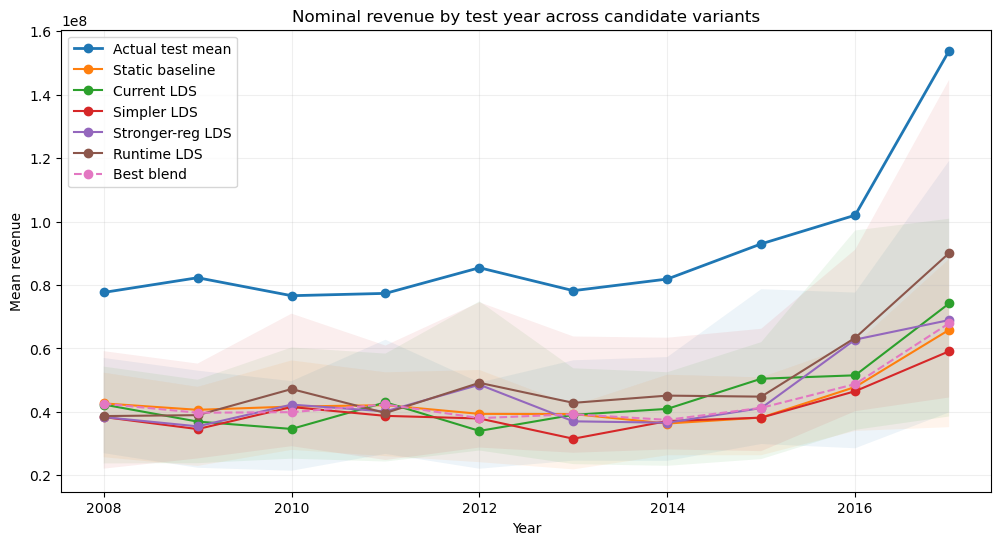

,year,actual_mean_revenue,static_baseline_mean_revenue,current_lds_mean_revenue,current_lds_low,current_lds_high,simpler_lds_mean_revenue,simpler_lds_low,simpler_lds_high,stronger_reg_lds_mean_revenue,stronger_reg_lds_low,stronger_reg_lds_high,runtime_lds_mean_revenue,runtime_lds_low,runtime_lds_high,blend_static_currentlds_w0.25_mean_revenue
0,2008,7.765123e+07,4.267630e+07,4.232106e+07,2.700022e+07,5.700377e+07,3.838699e+07,2.571603e+07,5.237174e+07,3.837253e+07,2.376194e+07,5.428547e+07,3.868651e+07,2.211243e+07,5.914605e+07,4.258749e+07
1,2009,8.228889e+07,4.066026e+07,3.694958e+07,2.239221e+07,5.300155e+07,3.458226e+07,2.297313e+07,4.790814e+07,3.544808e+07,2.384047e+07,5.014310e+07,3.897570e+07,2.533799e+07,5.522101e+07,3.973259e+07
2,2010,7.662475e+07,4.168617e+07,3.463173e+07,2.146172e+07,4.969305e+07,4.153146e+07,2.802201e+07,5.622128e+07,4.229745e+07,2.525532e+07,6.030711e+07,4.720147e+07,2.919923e+07,7.096269e+07,3.992256e+07
3,2011,7.735648e+07,4.211964e+07,4.301308e+07,2.676606e+07,6.273554e+07,3.875154e+07,2.605198e+07,5.249291e+07,4.015806e+07,2.435517e+07,5.838434e+07,3.965905e+07,2.483824e+07,6.091513e+07,4.234300e+07
4,2012,8.543854e+07,3.938446e+07,3.401107e+07,2.209326e+07,4.925703e+07,3.792858e+07,2.414905e+07,5.322158e+07,4.857653e+07,2.782733e+07,7.483350e+07,4.916446e+07,2.876567e+07,7.455569e+07,3.804111e+07
5,2013,7.820775e+07,3.932086e+07,3.907981e+07,2.463476e+07,5.626299e+07,3.154397e+07,2.188752e+07,4.200498e+07,3.703049e+07,2.353963e+07,5.374638e+07,4.285481e+07,2.713004e+07,6.376666e+07,3.926060e+07
6,2014,8.187652e+07,3.633831e+07,4.095523e+07,2.457075e+07,5.727783e+07,3.710597e+07,2.633168e+07,5.172983e+07,3.659430e+07,2.300727e+07,5.250550e+07,4.513373e+07,2.816856e+07,6.337882e+07,3.749254e+07
7,2015,9.296569e+07,3.822058e+07,5.046246e+07,2.988442e+07,7.866788e+07,3.819148e+07,2.635276e+07,5.088633e+07,4.121651e+07,2.512507e+07,6.198803e+07,4.481150e+07,2.762982e+07,6.620055e+07,4.128105e+07
8,2016,1.019996e+08,4.785071e+07,5.153213e+07,2.854126e+07,7.761494e+07,4.652573e+07,3.399306e+07,6.128090e+07,6.279139e+07,3.435351e+07,9.717780e+07,6.334551e+07,4.022940e+07,9.113001e+07,4.877106e+07
9,2017,1.538357e+08,6.586701e+07,7.418433e+07,3.985334e+07,1.191330e+08,5.911417e+07,3.519492e+07,8.818306e+07,6.894006e+07,3.854692e+07,1.008815e+08,9.006262e+07,4.454274e+07,1.446252e+08,6.794634e+07


In [8]:
test_df_base = prep_base['test_df']
test_years = np.sort(test_df_base['year'].unique())
yearly_rows = {year: np.where(test_df_base['year'].to_numpy() == year)[0] for year in test_years}

variant_plot_map = {
    'static_baseline': static_baseline,
    'current_lds': current_lds,
    'simpler_lds': simpler_lds,
    'stronger_reg_lds': stronger_reg_lds,
    'runtime_lds': runtime_lds,
    best_blend['name']: best_blend,
}

summary_rows = []
for year in test_years:
    idx = yearly_rows[year]
    row = {
        'year': year,
        'actual_mean_revenue': test_df_base.loc[test_df_base['year'] == year, 'revenue'].mean(),
    }
    for name, result in variant_plot_map.items():
        row[f'{name}_mean_revenue'] = result['test_pred_revenue'][idx].mean()
        if result['kind'] == 'lds':
            yearly_pred_samples = result['test_revenue_samples'][:, idx].mean(axis=1)
            row[f'{name}_low'] = np.quantile(yearly_pred_samples, 0.1)
            row[f'{name}_high'] = np.quantile(yearly_pred_samples, 0.9)
    summary_rows.append(row)

yearly_comparison_df = pd.DataFrame(summary_rows)

plt.figure(figsize=(12, 6))
plt.plot(yearly_comparison_df['year'], yearly_comparison_df['actual_mean_revenue'], marker='o', linewidth=2.0, label='Actual test mean')
plt.plot(yearly_comparison_df['year'], yearly_comparison_df['static_baseline_mean_revenue'], marker='o', label='Static baseline')
plt.plot(yearly_comparison_df['year'], yearly_comparison_df['current_lds_mean_revenue'], marker='o', label='Current LDS')
plt.plot(yearly_comparison_df['year'], yearly_comparison_df['simpler_lds_mean_revenue'], marker='o', label='Simpler LDS')
plt.plot(yearly_comparison_df['year'], yearly_comparison_df['stronger_reg_lds_mean_revenue'], marker='o', label='Stronger-reg LDS')
plt.plot(yearly_comparison_df['year'], yearly_comparison_df['runtime_lds_mean_revenue'], marker='o', label='Runtime LDS')
plt.plot(yearly_comparison_df['year'], yearly_comparison_df[f'{best_blend["name"]}_mean_revenue'], marker='o', linestyle='--', label='Best blend')
plt.fill_between(yearly_comparison_df['year'], yearly_comparison_df['current_lds_low'], yearly_comparison_df['current_lds_high'], alpha=0.08)
plt.fill_between(yearly_comparison_df['year'], yearly_comparison_df['simpler_lds_low'], yearly_comparison_df['simpler_lds_high'], alpha=0.08)
plt.fill_between(yearly_comparison_df['year'], yearly_comparison_df['stronger_reg_lds_low'], yearly_comparison_df['stronger_reg_lds_high'], alpha=0.08)
plt.fill_between(yearly_comparison_df['year'], yearly_comparison_df['runtime_lds_low'], yearly_comparison_df['runtime_lds_high'], alpha=0.08)
plt.title('Nominal revenue by test year across candidate variants')
plt.xlabel('Year')
plt.ylabel('Mean revenue')
plt.legend(loc='best')
plt.grid(alpha=0.2)
plt.show()

yearly_comparison_df


## Conclusion Helper

The final cell prints a short decision-oriented summary so the winning direction is obvious without reading the whole notebook.


In [9]:
best_overall = comparison_df.iloc[0]
lds_only_df = comparison_df[comparison_df['kind'] == 'lds'].copy()
static_row = comparison_df[comparison_df['variant'] == 'static_baseline'].iloc[0]
static_runtime_row = comparison_df[comparison_df['variant'] == 'static_baseline_runtime'].iloc[0]
best_lds_row = lds_only_df.sort_values(['test_rmse_revenue', 'test_mae_revenue', 'test_r2_revenue'], ascending=[True, True, False]).iloc[0]
any_lds_beats_static = bool((lds_only_df['test_rmse_revenue'] < static_row['test_rmse_revenue']).any())
best_blend_beats_all_direct = bool(best_blend['metrics']['test_rmse_revenue'] < comparison_df[comparison_df['kind'] != 'blend']['test_rmse_revenue'].min())

print('Best overall variant:')
print(f"  {best_overall['variant']}  |  test_rmse_revenue={best_overall['test_rmse_revenue']:.4f}  |  test_mae_revenue={best_overall['test_mae_revenue']:.4f}  |  test_r2_revenue={best_overall['test_r2_revenue']:.4f}")
print()
print('Best LDS variant:')
print(f"  {best_lds_row['variant']}  |  test_rmse_revenue={best_lds_row['test_rmse_revenue']:.4f}  |  test_mae_revenue={best_lds_row['test_mae_revenue']:.4f}  |  test_r2_revenue={best_lds_row['test_r2_revenue']:.4f}")
print()
print('Static baselines:')
print(f"  static_baseline         | test_rmse_revenue={static_row['test_rmse_revenue']:.4f}")
print(f"  static_baseline_runtime | test_rmse_revenue={static_runtime_row['test_rmse_revenue']:.4f}")
print()
print('Decision summary:')
print(f'  Any LDS beats static baseline: {any_lds_beats_static}')
print(f'  Best blend beats all direct models: {best_blend_beats_all_direct}')
print(f"  Selected blend candidate: {best_blend['name']}  |  test_rmse_revenue={best_blend['metrics']['test_rmse_revenue']:.4f}")


Best overall variant:
  static_baseline_runtime  |  test_rmse_revenue=138260244.5687  |  test_mae_revenue=54267933.6686  |  test_r2_revenue=0.4546

Best LDS variant:
  runtime_lds  |  test_rmse_revenue=144739554.6817  |  test_mae_revenue=57048690.8258  |  test_r2_revenue=0.4023

Static baselines:
  static_baseline         | test_rmse_revenue=151373957.1135
  static_baseline_runtime | test_rmse_revenue=138260244.5687

Decision summary:
  Any LDS beats static baseline: True
  Best blend beats all direct models: False
  Selected blend candidate: blend_static_currentlds_w0.25  |  test_rmse_revenue=151727481.9315


## Notes

This notebook is intentionally pragmatic. It uses the shared test set directly for model selection because the goal is to decide quickly which variant is worth carrying into the final ensemble-ready notebook.
